# Create visualizations of mAP vs cosine similarity vs single cell counts (post-QC)

In [ ]:
import pathlib

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_density,
    geom_hline,
    geom_point,
    geom_smooth,
    ggplot,
    labs,
    scale_fill_gradient2,
    scale_fill_manual,
    scale_size_continuous,
    theme,
    theme_bw,
)

In [2]:
# Load in merged single cell counts, mAP scores and cosine similarity scores
merged_map_cosine_sc_counts = pd.read_parquet(
    pathlib.Path("../figure_5/mAP_results/merged_map_with_cosine_and_sc_counts.parquet").resolve(strict=True)
)

# Set figure directory
figure_dir = pathlib.Path("./figures")
figure_dir.mkdir(parents=True, exist_ok=True)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/mAP_change_v_prop_failed_qc_by_dose.png


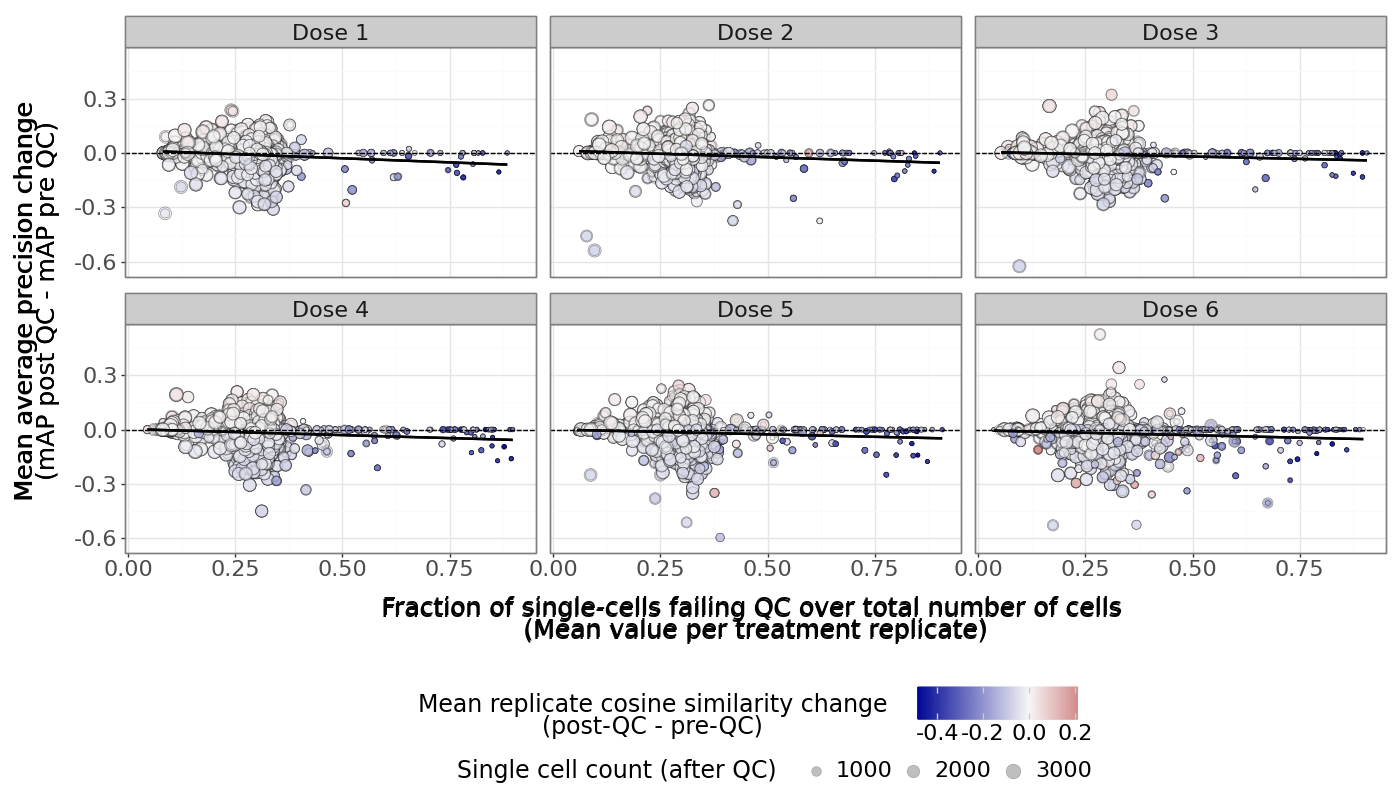

In [3]:
# Drop dose recode 0 and 7 due to small number of samples
merged_map_cosine_sc_counts_filtered = merged_map_cosine_sc_counts.query(
    "Metadata_dose_recode not in [0, 7]"
)

p = (
    ggplot(
        merged_map_cosine_sc_counts_filtered,
        aes(x="Metadata_avg_prop_failed_single_cells_postQC", y="mAP_change"),
    )
    # scatter
    + geom_point(
        aes(
            fill="mean_pairwise_cosine_similarity_change",
            size="Metadata_sc_count_passed_qc",
        ),
        color="black",
        stroke=0.25,
        alpha=0.25,
    )
    + scale_fill_gradient2(
        low="#000796",
        mid="#f7f7f7",
        high="#a60303",
        midpoint=0,
    )
    # regression per facet
    + geom_smooth(method="lm", color="black", se=False)
    # horizontal reference line
    + geom_hline(yintercept=0, linetype="dashed")
    # facet by dose
    + facet_wrap("~Metadata_dose_recode", ncol=3, labeller=lambda v: f"Dose {v}")
    # better size scaling
    + scale_size_continuous(range=(1, 6))
    # cleaner theme
    + theme_bw()
    + theme(
        figure_size=(14, 8),
        strip_text=element_text(size=16),
        axis_title=element_text(size=18),
        axis_text=element_text(size=16),
        # legend tuning (this is the important part)
        legend_title=element_text(size=17),
        legend_text=element_text(size=16),
        legend_position="bottom",
        legend_box="vertical",
    )
    + labs(
        x="Fraction of single-cells failing QC over total number of cells \n(Mean value per treatment replicate)",
        y="Mean average precision change\n(mAP post QC - mAP pre QC)",
        fill="Mean replicate cosine similarity change\n(post-QC - pre-QC)",
        size="Single cell count (after QC)",
    )
)


# Save plots
p.save(f"{figure_dir}/mAP_change_v_prop_failed_qc_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    for coll in ax.collections:
        coll.set_rasterized(True)

fig.savefig(f"{figure_dir}/mAP_change_v_prop_failed_qc_by_dose.svg", dpi=400)

p.show()

/tmp/ipykernel_3740317/1308227106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/cosine_similarity_by_mAP_direction_density.png


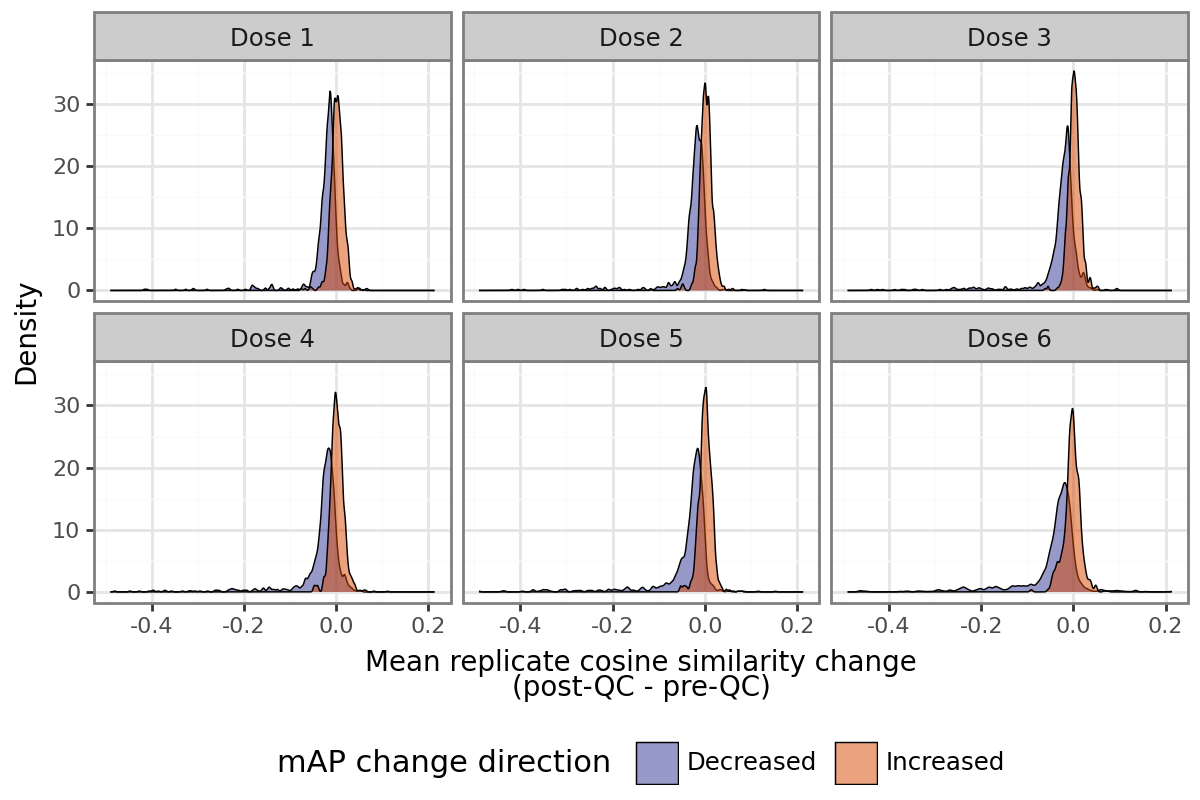

In [4]:
# Create a categorical label for mAP direction
merged_map_cosine_sc_counts_filtered["mAP_direction"] = np.where(
    merged_map_cosine_sc_counts_filtered["mAP_change"] > 0, "Increased", "Decreased"
)

# --- Option 1: overlaid density plot (best for direct shape comparison) ---
p_density = (
    ggplot(
        merged_map_cosine_sc_counts_filtered,
        aes(x="mean_pairwise_cosine_similarity_change", fill="mAP_direction"),
    )
    + geom_density(alpha=0.5, color="black", size=0.3)
    # + geom_vline(xintercept=0, linetype="dashed", color="red")
    + facet_wrap(
        "~Metadata_dose_recode", ncol=3, labeller=lambda v: f"Dose {v}"
    )
    + scale_fill_manual(values={"Increased": "#d94801", "Decreased": "#313695"})
    + theme_bw()
    + theme(
        legend_position="bottom",
        figure_size=(6,4),
        axis_title=element_text(size=10),
        axis_text=element_text(size=8),
    )
    + labs(
        x="Mean replicate cosine similarity change\n(post-QC - pre-QC)",
        y="Density",
        fill="mAP change direction",
    )
)
p_density.save(f"{figure_dir}/cosine_similarity_by_mAP_direction_density.png", dpi=600)
p_density.show()
